In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [48]:
df = pd.read_csv('height-weight.csv')

In [49]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'height')

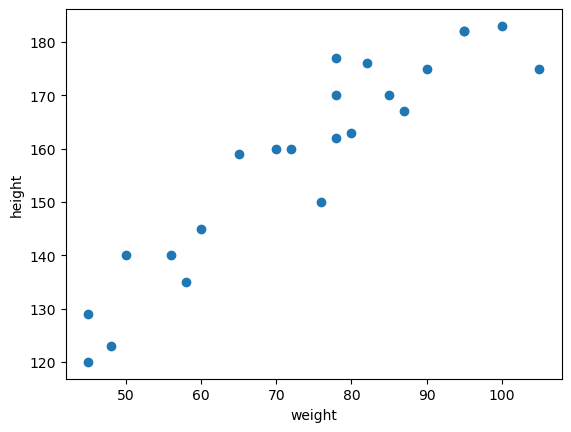

In [50]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel("weight")
plt.ylabel("height")

In [51]:
X = df[['Weight']]
y = df['Height']

In [52]:
## Train test split
from sklearn.model_selection import train_test_split

In [53]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state =42)

In [54]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

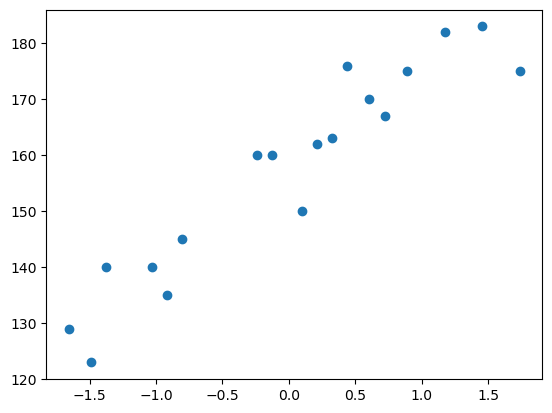

In [55]:
plt.scatter(X_train, y_train)

In [56]:
from sklearn.linear_model import LinearRegression

In [57]:
regressor = LinearRegression()

In [58]:
regressor

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [60]:
print("The slope or coefficient is", regressor.coef_)
print("The intercept is", regressor.intercept_)

The slope or coefficient is [17.03440872]
The intercept is 157.5


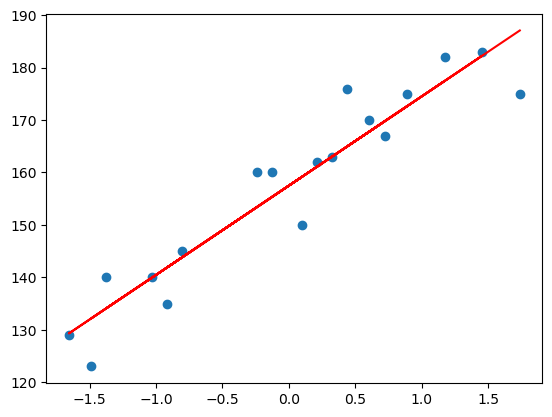

In [61]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regressor.predict(X_train), 'r')

In [62]:
## prediction for the training data
y_pred_test = regressor.predict(X_test)

In [63]:
y_pred_test, y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

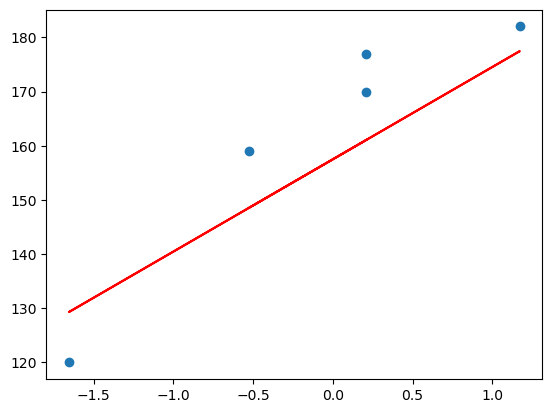

In [64]:
plt.scatter(X_test, y_test)
plt.plot(X_test, regressor.predict(X_test), 'r')

In [65]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [66]:
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

109.77592599051664
9.822657814519232
10.477400726827081


In [67]:
## R - Square

In [68]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred_test)

In [69]:
score

0.776986986042344

In [70]:
## Adjusted R square

In [71]:
1 - ((1-score) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1]-1))

0.7026493147231252

In [72]:
regressor

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [73]:
## predict the new data point
scaled_weight = scaler.transform([[80]])
scaled_weight

c:\Users\Siddhant\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [74]:
scaled_weight[0]

array([0.32350772])

In [75]:
regressor.predict(scaled_weight)

array([163.01076266])

In [76]:
## Assumptions

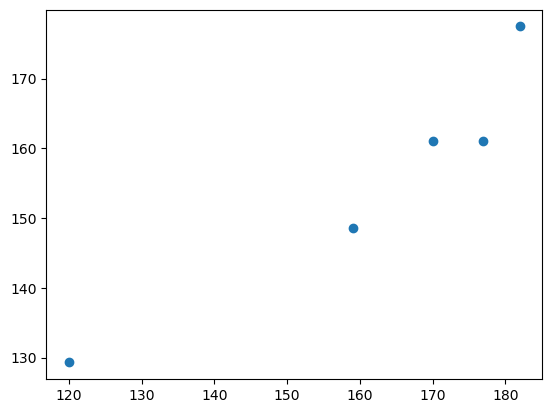

In [77]:
plt.scatter(y_test, y_pred_test)

In [78]:
residuals = y_test-y_pred_test
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

In [79]:
import seaborn as sns

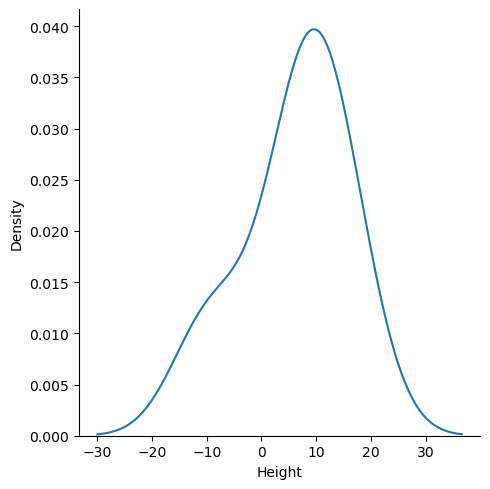

In [84]:
sns.displot(residuals, kind = 'kde')

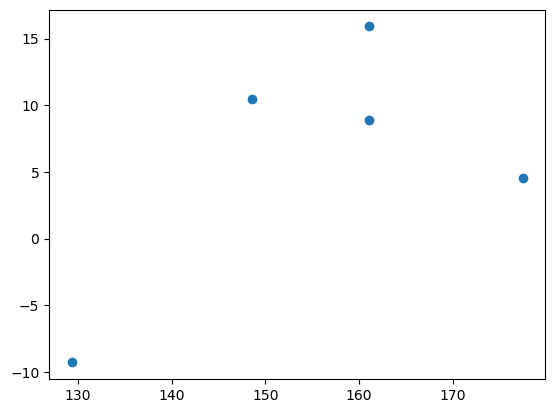

In [82]:
plt.scatter(y_pred_test, residuals)